Extract the surface values of turbidity

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
base_dir = Path("../data/")
upct_dir = base_dir / "raw/UPCT"
output_file = base_dir / "datasets/UPCT_turbidity_surface.csv"
image_dir = base_dir / "satellite"
out_dir = base_dir / "datasets"
out_dir.mkdir(parents=True, exist_ok=True)

In [4]:
INCLUDE_CTD5 = False
INCLUDE_CTD9 = True

In [5]:
upct_files = sorted(upct_dir.glob("CTD*_turbidity.csv"))

if not INCLUDE_CTD5:
    upct_files = [f for f in upct_files if "CTD5" not in f.name]

dfs = []

for path in upct_files:
    df = pd.read_csv(path).dropna(axis=1, how="all")

    depth_cols = [c for c in df.columns if c != "Date"]
    shallow_col = min(depth_cols, key=lambda c: float(c))

    out = df[["Date", shallow_col]].copy()
    out.columns = ["date", "turbidity"]
    out["ctd"] = path.stem.split("_")[0]
    out["date"] = pd.to_datetime(out["date"])

    dfs.append(out)

final_df = pd.concat(dfs, ignore_index=True)
final_df.to_csv(output_file, index=False)

In [6]:
date_sets = {}
date_counts = {}

for path in upct_files:
    station = path.name.split("_")[0]
    df = pd.read_csv(path, usecols=["Date"])

    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    dates = set(df["Date"].dropna())

    date_sets[station] = dates
    date_counts[station] = len(dates)

all_stations = list(date_sets.keys())

reference = all_stations[0]
reference_dates = date_sets[reference]

comparison = []

for station in all_stations:
    missing_in_station = reference_dates - date_sets[station]
    extra_in_station = date_sets[station] - reference_dates
    comparison.append({
        "station": station,
        "n_dates": date_counts[station],
        "missing_vs_reference": len(missing_in_station),
        "extra_vs_reference": len(extra_in_station),
        "same_as_reference": date_sets[station] == reference_dates
    })

result_df = pd.DataFrame(comparison).sort_values("station")
result_df

,station,n_dates,missing_vs_reference,extra_vs_reference,same_as_reference
3,CTD1,379,0,0,True
0,CTD10,379,0,0,True
1,CTD11,379,0,0,True
2,CTD12,379,0,0,True
4,CTD2,379,0,0,True
5,CTD3,379,0,0,True
6,CTD4,379,0,0,True
7,CTD6,379,0,0,True
8,CTD7,379,0,0,True
9,CTD8,379,0,0,True


Satellital imagery

In [7]:
dates = sorted(set(
    f.name.split("_")[0]
    for f in list(image_dir.glob("*.tif"))
    if "_" in f.name
))

print(len(dates))
print(dates)

43
['2023-01-05', '2023-01-07', '2023-01-10', '2023-01-20', '2023-01-21', '2023-01-23', '2023-01-29', '2023-01-30', '2023-01-31', '2023-02-01', '2023-02-04', '2023-02-05', '2023-02-07', '2023-02-11', '2023-02-27', '2023-03-01', '2023-03-16', '2023-03-22', '2023-03-29', '2023-06-21', '2023-08-17', '2023-08-24', '2023-10-05', '2023-10-17', '2023-11-08', '2023-11-16', '2023-11-24', '2023-12-07', '2023-12-19', '2023-12-27', '2024-01-09', '2024-01-16', '2024-01-23', '2024-02-13', '2024-02-20', '2024-03-13', '2024-04-10', '2024-04-24', '2024-05-22', '2024-05-29', '2024-06-18', '2024-06-25', '2024-07-03']


### Match CTD with satellite dates

Loads the CTD CSV and cleans the `date` column.
Extracts dates from `*composite.tif` filenames.
Performs an inner join by date to keep only matches.
Saves the result to `turbidity_ctd_satellite.csv` and prints the number of matches.

In [10]:
ctd = pd.read_csv(output_file)
ctd["date"] = pd.to_datetime(ctd["date"], errors="coerce").dt.date
ctd = ctd.dropna(subset=["date"])

satellite_dir = Path("../data/satellite")
tif_files = list(satellite_dir.glob("*composite.tif"))

dates = sorted(set(f.name.split("_")[0] for f in tif_files if "_" in f.name))

sat_df = pd.DataFrame({"date": pd.to_datetime(dates, errors="coerce")})
sat_df = sat_df.dropna()
sat_df["date"] = sat_df["date"].dt.date

matched = ctd.merge(sat_df, on="date", how="inner")
matched = matched.reset_index(drop=True)

matched.to_csv(out_dir / "turbidity_ctd_satellite.csv", index=False)

print(len(matched))

341


### Dataset statistics and EDA

Loads and cleans the merged dataset, prints structure and missing values.
Computes per-station turbidity statistics.
Plots distribution, temporal evolution, and monthly seasonality.
Calculates missing ratios and encodes `ctd` as categorical codes.

Shape: (341, 3)

Columns: ['date', 'turbidity', 'ctd']

Missing values:
 date         0
turbidity    0
ctd          0
dtype: int64

Per-ctd statistics:
        count      mean       std       min        max
ctd                                                  
CTD1      31  0.966104  0.803718  0.000000   3.473128
CTD10     31  1.257444  1.596114  0.000000   9.373759
CTD11     31  0.889645  1.170085  0.000000   6.427054
CTD12     31  1.225967  1.352640  0.049275   8.097196
CTD2      31  1.306718  0.784002  0.077854   3.063226
CTD3      31  1.051253  0.591980  0.362950   2.647561
CTD4      31  0.814044  0.577594  0.101836   2.465000
CTD6      31  1.130307  0.981171  0.424036   5.983576
CTD7      31  1.937436  1.649828  0.000000   8.624921
CTD8      31  1.559336  1.522973  0.000000   8.969757
CTD9      31  1.575763  1.785869  0.000000  10.488461


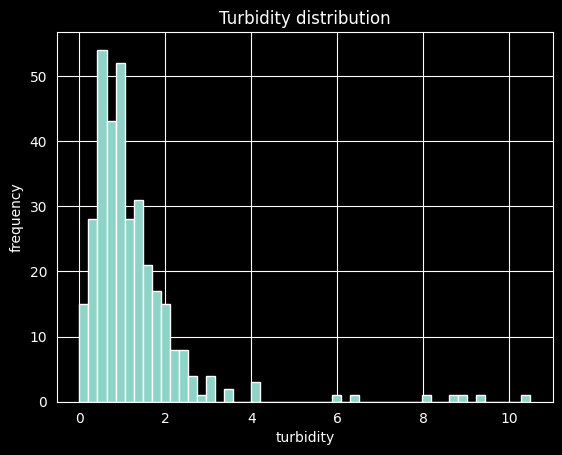

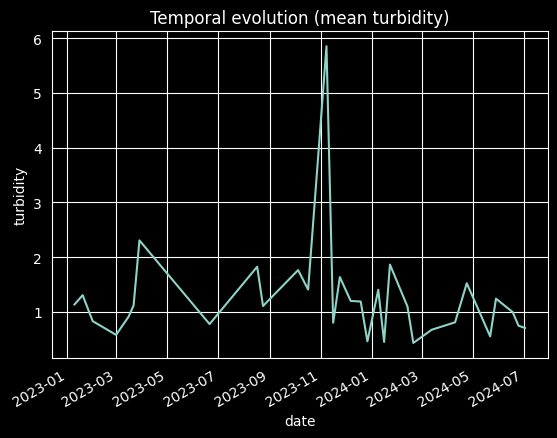


Missing ratio:
 date         0.0
turbidity    0.0
ctd          0.0
dtype: float64


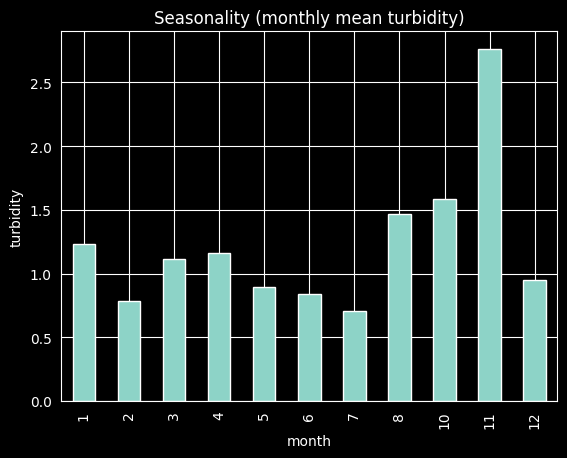

In [11]:
base_dir = Path("../data")
file_path = base_dir / "datasets" / "turbidity_ctd_satellite.csv"

df = pd.read_csv(file_path)

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date"])
df = df.sort_values(["ctd", "date"])

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isna().sum())

target_col = "turbidity"
df[target_col] = pd.to_numeric(df[target_col], errors="coerce")

summary = df.groupby("ctd")[target_col].agg(["count", "mean", "std", "min", "max"])
print("\nPer-ctd statistics:\n", summary)

plt.figure()
df[target_col].hist(bins=50)
plt.title("Turbidity distribution")
plt.xlabel("turbidity")
plt.ylabel("frequency")
plt.show()

plt.figure()
df.groupby("date")[target_col].mean().plot()
plt.title("Temporal evolution (mean turbidity)")
plt.xlabel("date")
plt.ylabel("turbidity")
plt.show()

missing_ratio = df.isna().mean().sort_values(ascending=False)
print("\nMissing ratio:\n", missing_ratio)

df["month"] = df["date"].dt.month
seasonality = df.groupby("month")[target_col].mean()

plt.figure()
seasonality.plot(kind="bar")
plt.title("Seasonality (monthly mean turbidity)")
plt.xlabel("month")
plt.ylabel("turbidity")
plt.show()

#df["ctd"] = df["ctd"].astype("category").cat.codes

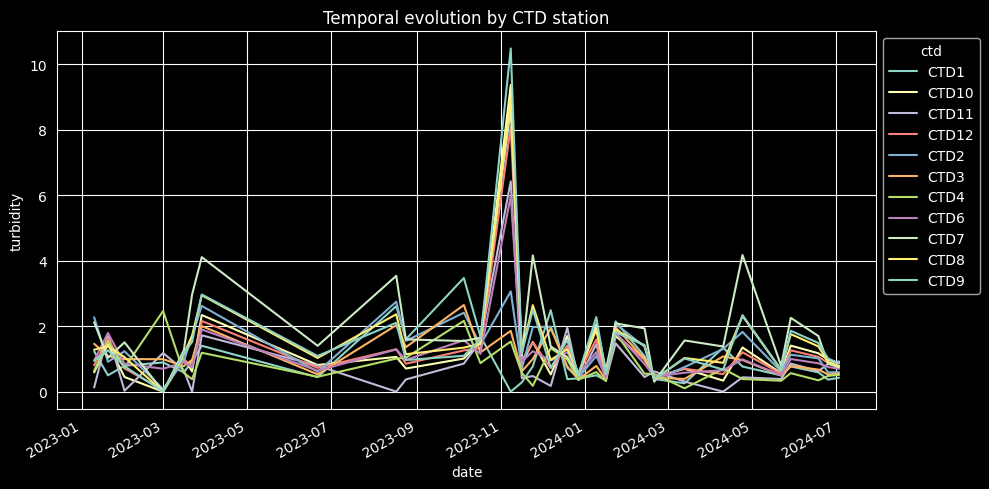

In [12]:
plt.figure(figsize=(10, 5))

df["ctd"] = df["ctd"].astype(str)

for station, g in df.groupby("ctd"):
    g.groupby("date")["turbidity"].mean().plot(label=station)

plt.legend(title="ctd", loc="upper left", bbox_to_anchor=(1, 1))
plt.title("Temporal evolution by CTD station")
plt.xlabel("date")
plt.ylabel("turbidity")

plt.tight_layout()
plt.show()

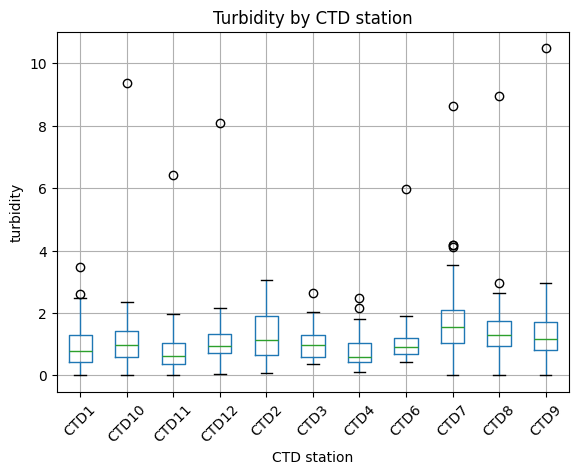

In [13]:
plt.style.use("default")

df["ctd"] = df["ctd"].astype(str)

fig, ax = plt.subplots()
ax.set_facecolor("white")
fig.patch.set_facecolor("white")

df.boxplot(column="turbidity", by="ctd", ax=ax)

ax.set_title("Turbidity by CTD station")
ax.set_xlabel("CTD station")
ax.set_ylabel("turbidity")

plt.suptitle("")
plt.xticks(rotation=45)
plt.show()

In [14]:
df_y = pd.read_csv("../data/datasets/turbidity_ctd_satellite.csv")
df_y.head()

,date,turbidity,ctd
0,2023-01-10,0.589949,CTD10
1,2023-01-20,1.445618,CTD10
2,2023-02-01,0.448155,CTD10
3,2023-03-01,0.000000,CTD10
4,2023-03-16,1.016013,CTD10


Skewness: 4.179700302700354
Kurtosis: 22.949509687459138


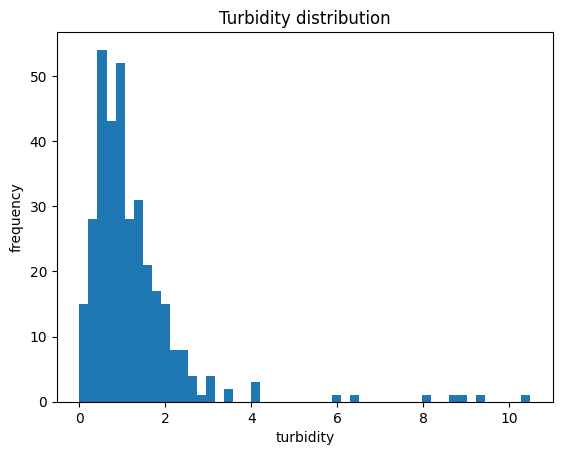

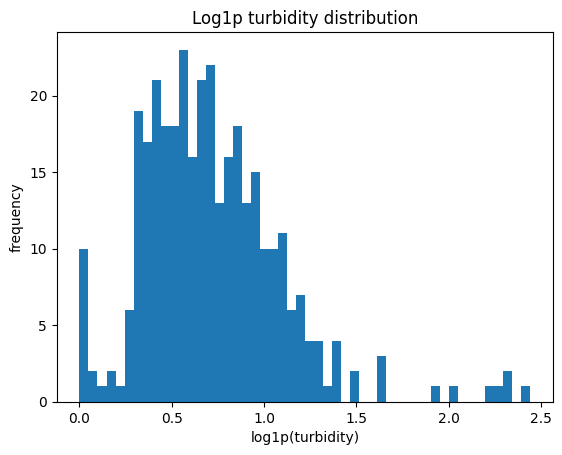

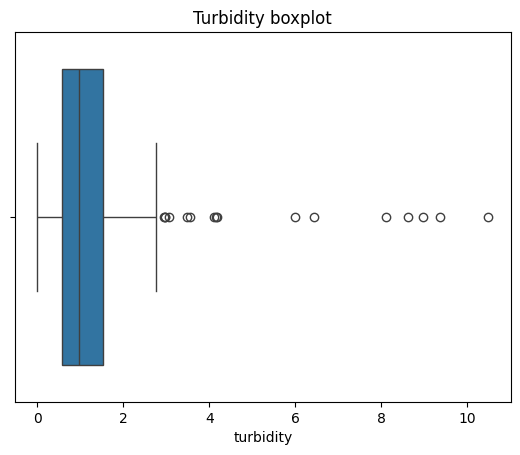

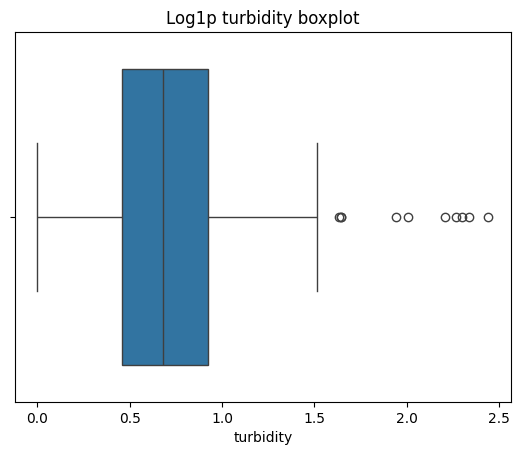

In [15]:
target = "turbidity"

df[target] = pd.to_numeric(df[target], errors="coerce")
x = df[target].dropna()

print("Skewness:", x.skew())
print("Kurtosis:", x.kurtosis())

plt.figure()
plt.hist(x, bins=50)
plt.title("Turbidity distribution")
plt.xlabel("turbidity")
plt.ylabel("frequency")
plt.show()

plt.figure()
plt.hist(np.log1p(x), bins=50)
plt.title("Log1p turbidity distribution")
plt.xlabel("log1p(turbidity)")
plt.ylabel("frequency")
plt.show()

plt.figure()
sns.boxplot(x=x)
plt.title("Turbidity boxplot")
plt.show()

plt.figure()
sns.boxplot(x=np.log1p(x))
plt.title("Log1p turbidity boxplot")
plt.show()

In [16]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import PowerTransformer
from catboost import CatBoostRegressor

target = "turbidity"

df_model = df.dropna(subset=[target]).copy()

features = df_model.drop(columns=[target])
y = df_model[target].astype(float)

X = features.select_dtypes(include=[np.number]).fillna(0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

results = {}

def evaluate(name, y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred))
    }

models = {}

# 1. No transform
m1 = HistGradientBoostingRegressor()
m1.fit(X_train, y_train)
pred1 = m1.predict(X_test)
results["no_transform"] = evaluate("no_transform", y_test, pred1)

# 2. Log transform
y_train_log = np.log1p(y_train)
m2 = HistGradientBoostingRegressor()
m2.fit(X_train, y_train_log)
pred2 = np.expm1(m2.predict(X_test))
results["log1p"] = evaluate("log1p", y_test, pred2)

# 3. Yeo-Johnson
pt = PowerTransformer(method="yeo-johnson")
y_train_yj = pt.fit_transform(y_train.values.reshape(-1, 1)).ravel()

m3 = HistGradientBoostingRegressor()
m3.fit(X_train, y_train_yj)
pred3 = pt.inverse_transform(m3.predict(X_test).reshape(-1, 1)).ravel()
results["yeo_johnson"] = evaluate("yeo_johnson", y_test, pred3)

# 4. CatBoost (log)
m4 = CatBoostRegressor(verbose=0)
m4.fit(X_train, y_train_log)
pred4 = np.expm1(m4.predict(X_test))
results["catboost_log"] = evaluate("catboost_log", y_test, pred4)

# 5. CatBoost no transform
m5 = CatBoostRegressor(verbose=0)
m5.fit(X_train, y_train)
pred5 = m5.predict(X_test)
results["catboost_no_transform"] = evaluate("catboost_no_transform", y_test, pred5)

for k, v in results.items():
    print(k, v)

no_transform {'MAE': 0.7107112227399739, 'RMSE': np.float64(1.2926013504207077)}
log1p {'MAE': 0.680028160726036, 'RMSE': np.float64(1.3690353456000959)}
yeo_johnson {'MAE': 0.6811841437562947, 'RMSE': np.float64(1.4249201948804266)}
catboost_log {'MAE': 0.6789810671315385, 'RMSE': np.float64(1.3690513783118818)}
catboost_no_transform {'MAE': 0.7097103733193771, 'RMSE': np.float64(1.2923730912635003)}
